In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/train.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv
/kaggle/input/playground-series-s3e18/train.csv
/kaggle/input/playground-series-s3e18/description.md
/kaggle/input/playground-series-s3e18/sample_submission.csv.zip
/kaggle/input/playground-series-s3e18/test.csv.zip
/kaggle/input/playground-series-s3e18/train.csv.zip
/kaggle/input/playground-series-s3e18/test.csv
/kaggle/input/playground-series-s3e18/sample_submission.csv


In [2]:
import pandas as pd

df_train = pd.read_csv("/kaggle/input/playground-series-s3e18/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s3e18/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/input/playground-series-s3e18/sample_submission.csv"
)



In [3]:
df_train.head()



,id,BertzCT,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3v,Chi4n,EState_VSA1,...,SlogP_VSA3,VSA_EState9,fr_COO,fr_COO2,EC1,EC2,EC3,EC4,EC5,EC6
0,3305,212.928441,6.270857,3.431698,4.045502,1.811731,2.272429,1.619489,0.828835,7.822697,...,13.825658,36.819857,0,0,1,1,0,1,0,0
1,8217,221.694355,4.060660,3.548618,3.548618,2.499652,2.499652,1.607504,0.883813,17.980451,...,9.589074,39.833333,2,2,1,0,0,1,0,0
2,12616,159.130752,4.414719,2.801636,2.801636,2.676274,2.676274,1.204209,0.361282,12.011146,...,11.215359,33.500000,1,1,1,1,0,0,0,0
3,10153,1239.282494,16.098662,10.151117,10.151117,11.008637,11.008637,7.914542,3.408511,5.969305,...,9.589074,73.500000,1,1,1,1,0,0,0,0
4,9564,574.170559,8.417121,5.143525,5.143525,3.478542,3.478542,2.264463,2.087653,5.969305,...,4.794537,39.166667,1,1,1,0,0,1,0,0


findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Fon

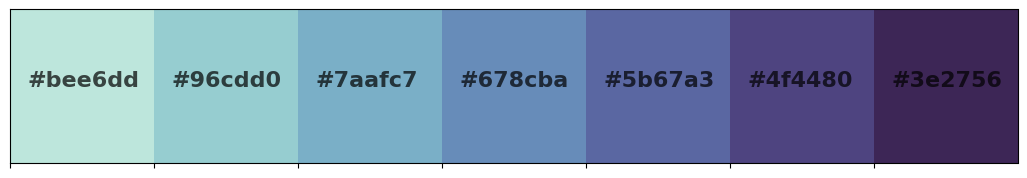

In [4]:
my_palette = sns.cubehelix_palette(
    n_colors=7, start=0.46, rot=-0.45, dark=0.2, hue=0.95
)
sns.palplot(my_palette)
plt.gcf().set_size_inches(13, 2)

for idx, values in enumerate(my_palette.as_hex()):
    plt.text(
        idx - 0.375,
        0,
        my_palette.as_hex()[idx],
        {"font": "Courier New", "size": 16, "weight": "bold", "color": "black"},
        alpha=0.7,
    )
plt.gcf().set_facecolor("white")

plt.show()



In [5]:
df_train.describe().T



,count,mean,std,min,25%,50%,75%,max
id,13354.0,7430.046054,4280.726674,0.000000,3725.250000,7424.500000,11138.750000,14837.000000
BertzCT,13354.0,515.344063,541.590240,0.000000,149.874524,292.455280,652.281490,4069.959780
Chi1,13354.0,9.135106,6.811711,0.000000,4.680739,6.494089,11.170340,69.551167
Chi1n,13354.0,5.854336,4.641652,0.000000,2.854294,4.059093,7.486482,50.174588
Chi1v,13354.0,6.741385,5.859587,0.000000,2.932842,4.392859,8.527859,53.431954
Chi2n,13354.0,4.434309,3.759906,0.000000,1.949719,2.970427,5.788793,32.195368
Chi2v,13354.0,5.251854,4.914257,0.000000,2.037238,3.261677,6.621896,34.579313
Chi3v,13354.0,3.416554,3.425819,0.000000,1.162568,1.951087,4.502070,22.589276
Chi4n,13354.0,1.772391,1.860338,0.000000,0.508512,1.077096,2.540348,16.072810
EState_VSA1,13354.0,29.207586,31.755738,0.000000,5.969305,17.353601,44.876559,363.705954


In [6]:
df_train.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 13354 non-null  int64  
 1   BertzCT            13354 non-null  float64
 2   Chi1               13354 non-null  float64
 3   Chi1n              13354 non-null  float64
 4   Chi1v              13354 non-null  float64
 5   Chi2n              13354 non-null  float64
 6   Chi2v              13354 non-null  float64
 7   Chi3v              13354 non-null  float64
 8   Chi4n              13354 non-null  float64
 9   EState_VSA1        13354 non-null  float64
 10  EState_VSA2        13354 non-null  float64
 11  ExactMolWt         13354 non-null  float64
 12  FpDensityMorgan1   13354 non-null  float64
 13  FpDensityMorgan2   13354 non-null  float64
 14  FpDensityMorgan3   13354 non-null  float64
 15  HallKierAlpha      13354 non-null  float64
 16  HeavyAtomMolWt     133

In [7]:
df_train[["MaxAbsEStateIndex", "MinEStateIndex"]].head()



,MaxAbsEStateIndex,MinEStateIndex
0,10.893972,-4.947221
1,9.226852,-1.165509
2,10.636065,-1.500880
3,11.526326,-1.439086
4,10.484861,-0.985000


In [8]:
# BUGFIX: Keep id for submission alignment; create separate feature matrices without id.
train_ids = df_train["id"].copy()
test_ids = df_test["id"].copy()



In [9]:
target_col1 = "EC1"
target_col2 = "EC2"
num_cols = [
    "BertzCT",
    "Chi1",
    "Chi1n",
    "Chi1v",
    "Chi2n",
    "Chi2v",
    "Chi3v",
    "Chi4n",
    "EState_VSA1",
    "EState_VSA2",
    "ExactMolWt",
    "FpDensityMorgan1",
    "FpDensityMorgan2",
    "FpDensityMorgan3",
    "HallKierAlpha",
    "HeavyAtomMolWt",
    "Kappa3",
    "MaxAbsEStateIndex",
    "MinEStateIndex",
    "NumHeteroatoms",
    "PEOE_VSA10",
    "PEOE_VSA14",
    "PEOE_VSA6",
    "PEOE_VSA7",
    "PEOE_VSA8",
    "SMR_VSA10",
    "SMR_VSA5",
    "SlogP_VSA3",
    "VSA_EState9",
]
binary_cols = ["EC1", "EC2", "EC3", "EC4", "EC5", "EC6"]
cat_cols = df_test.select_dtypes(include=["object"]).columns.tolist()

print(f"[INFO] Shapes:" f"\n train: {df_train.shape}" f"\n test: {df_test.shape}\n")

print(
    f"[INFO] Any missing values:"
    f"\n train: {df_train.isna().any().any()}"
    f"\n test: {df_test.isna().any().any()}"
)



[INFO] Shapes:
 train: (13354, 38)
 test: (1484, 32)

[INFO] Any missing values:
 train: False
 test: False


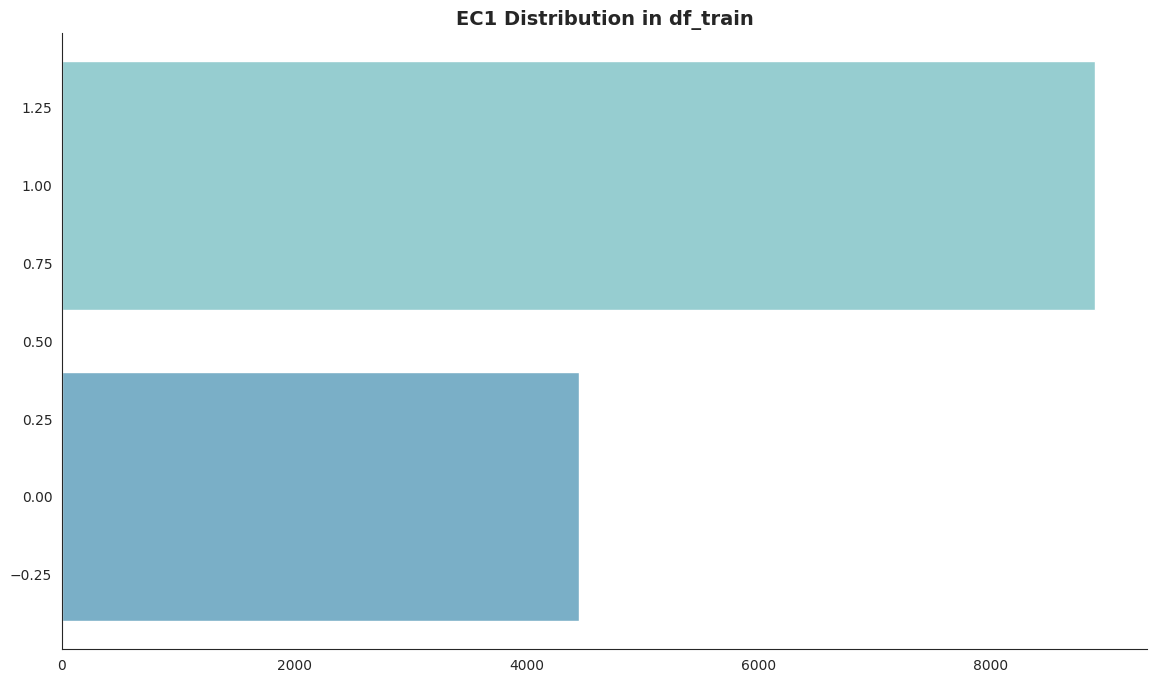

In [10]:
plt.figure(figsize=(14, 8))
sns.set_style("white")

colors = my_palette

plt.barh(
    df_train[target_col1].value_counts().index,
    df_train[target_col1].value_counts(),
    color=colors[1:3],
)

plt.title("EC1 Distribution in df_train", fontsize=14, fontweight="bold")

sns.despine()

plt.show()



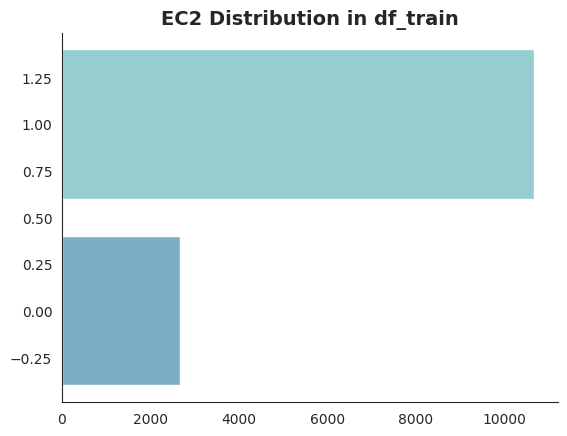

In [11]:
plt.barh(
    df_train[target_col2].value_counts().index,
    df_train[target_col2].value_counts(),
    color=colors[1:3],
)

plt.title("EC2 Distribution in df_train", fontsize=14, fontweight="bold")

sns.despine()

plt.show()



In [12]:
# BUGFIX: Ludwig import fails in this environment due to torchtext binary mismatch.
# We keep the overall approach (separate binary models for EC1 and EC2 producing probabilities)
# but implement it with scikit-learn which is available and stable.
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression



In [13]:
# BUGFIX: Original code power_transformed the entire df_train (including EC targets),
# which is incorrect and can break modeling. Transform only feature columns.
feature_cols = [c for c in df_train.columns if c not in (["id"] + binary_cols)]
X_train = df_train[feature_cols].copy()
X_test = df_test[feature_cols].copy()
y1 = df_train[target_col1].astype(int).values
y2 = df_train[target_col2].astype(int).values

print("[INFO] Feature matrix shapes:", X_train.shape, X_test.shape)




[INFO] Feature matrix shapes: (13354, 31) (1484, 31)


In [14]:
def out_iqr(df):
    columns = df.columns
    iqrs, lower_out, upper_out = [], [], []
    for column in columns:
        q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
        iqr = q75 - q25
        cut_off = iqr * 1.5
        lower, upper = q25 - cut_off, q75 + cut_off
        df1 = df[df[column] > upper].shape[0]
        df2 = df[df[column] < lower].shape[0]
        iqrs.append(iqr)
        upper_out.append(df1)
        lower_out.append(df2)
    return pd.DataFrame(
        data={
            "columns": df.columns,
            "iqr": iqrs,
            "lower_outliers": lower_out,
            "upper_outliers": upper_out,
        }
    ).style.background_gradient(axis=0, cmap="Greens")




In [15]:
# Keep the original EDA utility callable, but run it on transformed copies of FEATURES only.
df_tr_copy = X_train.copy()
df_tst_copy = X_test.copy()

# If there are missing values, PowerTransformer can't handle NaNs; impute for visualization.
_tmp_imp = SimpleImputer(strategy="median")
df_tr_copy.iloc[:, :] = _tmp_imp.fit_transform(df_tr_copy)
df_tst_copy.iloc[:, :] = _tmp_imp.transform(df_tst_copy)

df_tr_copy.iloc[:, :] = PowerTransformer(method="yeo-johnson").fit_transform(df_tr_copy)
df_tst_copy.iloc[:, :] = PowerTransformer(method="yeo-johnson").fit_transform(
    df_tst_copy
)

out_iqr(df_tr_copy)



/tmp/ipykernel_11/1629535627.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.49909148 -0.23689306 -0.52017956 ... -0.52017956 -0.23689306
  0.49909148]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_tr_copy.iloc[:, :] = PowerTransformer(method="yeo-johnson").fit_transform(df_tr_copy)
/tmp/ipykernel_11/1629535627.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.76452534  1.56408959  1.22353491 ...  1.22353491  1.22353491
  1.22353491]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_tr_copy.iloc[:, :] = PowerTransformer(method="yeo-johnson").fit_transform(df_tr_copy)
/tmp/ipykernel_11/1629535627.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.76619094  1.563366

,columns,iqr,lower_outliers,upper_outliers
0,BertzCT,1.321586,181,10
1,Chi1,1.290858,149,4
2,Chi1n,1.311414,145,4
3,Chi1v,1.355721,136,1
4,Chi2n,1.349590,0,1
5,Chi2v,1.356701,0,0
6,Chi3v,1.392904,0,0
7,Chi4n,1.527379,0,0
8,EState_VSA1,1.388473,0,2
9,EState_VSA2,1.874473,0,0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

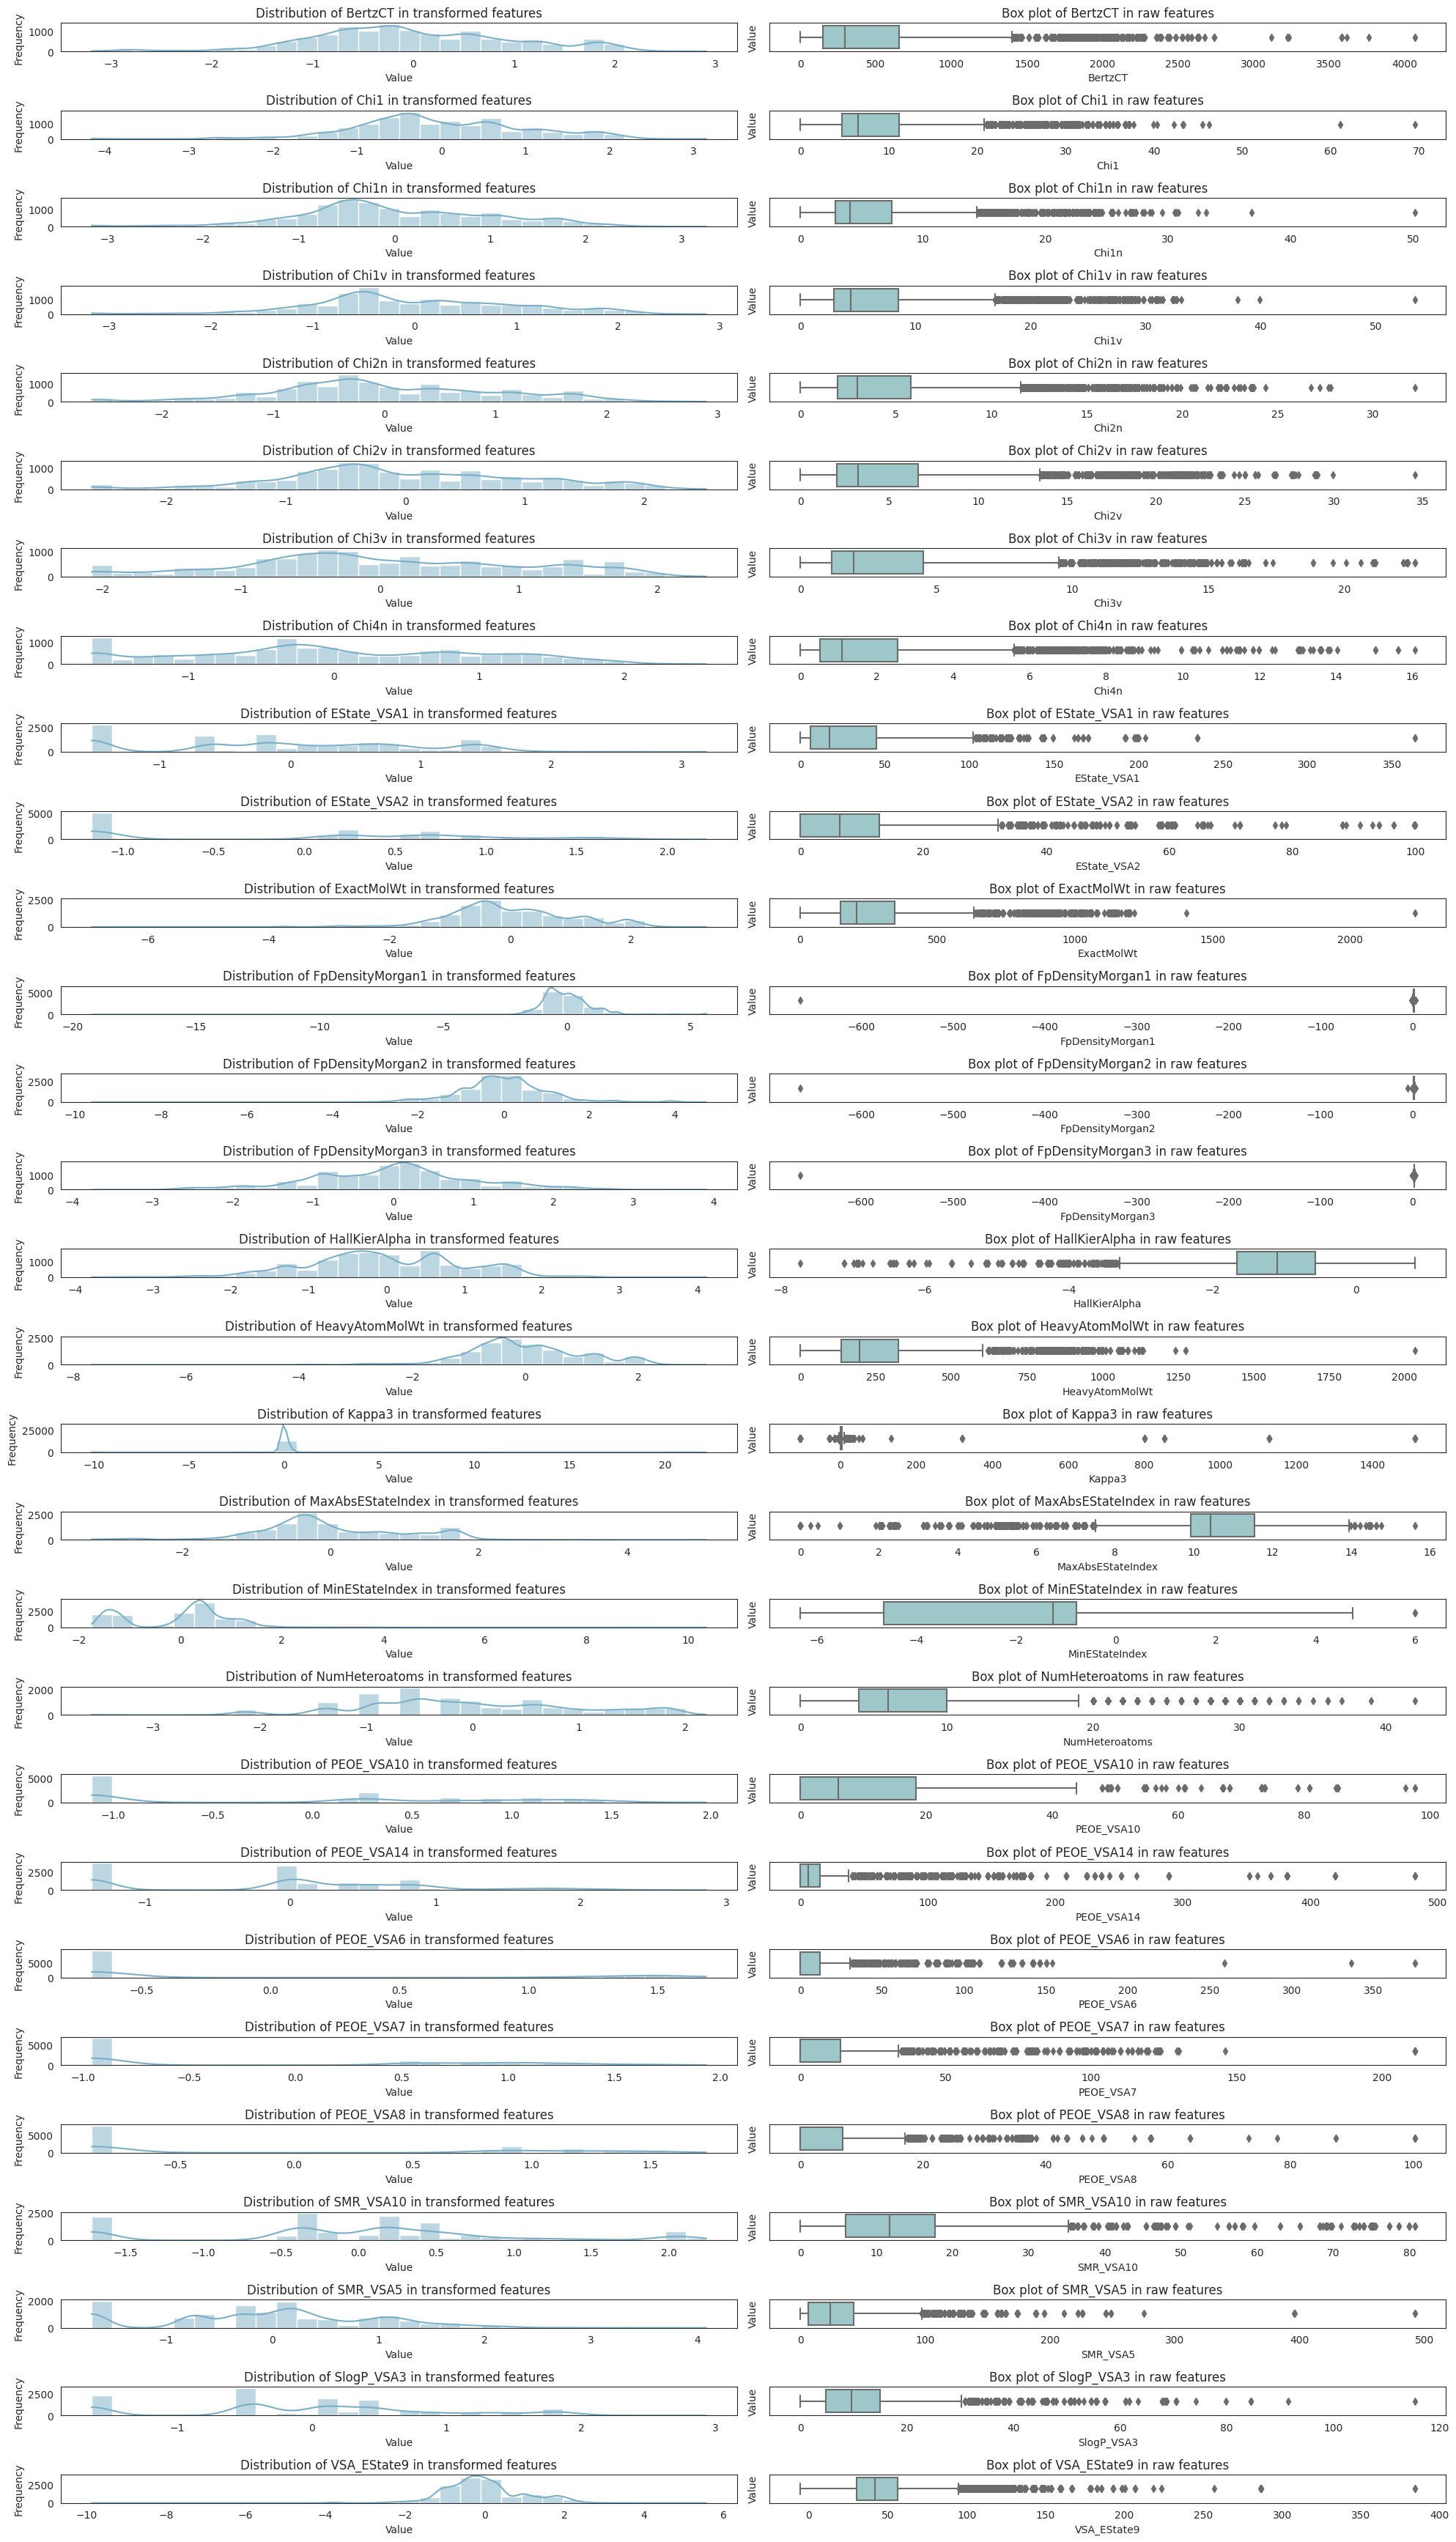

In [16]:
# Retain plotting cell (may be slow but functional).
numerical_columns = [c for c in num_cols if c in df_tr_copy.columns]

fig, axes = plt.subplots(
    len(numerical_columns), 2, figsize=(20, max(6, 1.2 * len(numerical_columns)))
)

for i, column in enumerate(numerical_columns):
    sns.histplot(
        df_tr_copy[column], bins=30, kde=True, ax=axes[i, 0], color=my_palette[2]
    )
    axes[i, 0].set_title(f"Distribution of {column} in transformed features")
    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")

    sns.boxplot(x=X_train[column], ax=axes[i, 1], color=my_palette[1])
    axes[i, 1].set_title(f"Box plot of {column} in raw features")
    axes[i, 1].set_xlabel(column)
    axes[i, 1].set_ylabel("Value")

plt.tight_layout()
plt.show()




In [17]:
# Replacement for Ludwig config/model instantiation:
# Two separate binary classifiers using the same preprocessing pipeline.
def make_model(random_state: int = 42):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("power", PowerTransformer(method="yeo-johnson")),
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=random_state,
                ),
            ),
        ]
    )


model_ec1 = make_model(42)
model_ec2 = make_model(43)



In [18]:
# Optional quick CV sanity-check for stability (does not change training approach; just diagnostics).
# Keep it lightweight to avoid timeout.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc1 = cross_val_score(
    model_ec1, X_train, y1, cv=cv, scoring="roc_auc", n_jobs=-1
).mean()
auc2 = cross_val_score(
    model_ec2, X_train, y2, cv=cv, scoring="roc_auc", n_jobs=-1
).mean()
print(f"[INFO] CV AUC EC1: {auc1:.5f} | EC2: {auc2:.5f} | mean: {(auc1+auc2)/2:.5f}")



[INFO] CV AUC EC1: 0.67210 | EC2: 0.57226 | mean: 0.62218


In [19]:
# Train final models on full training data and predict probabilities on test.
model_ec1.fit(X_train, y1)
model_ec2.fit(X_train, y2)

pred_ec1 = model_ec1.predict_proba(X_test)[:, 1]
pred_ec2 = model_ec2.predict_proba(X_test)[:, 1]

print("[INFO] Predictions shapes:", pred_ec1.shape, pred_ec2.shape)



[INFO] Predictions shapes: (1484,) (1484,)


In [20]:
# Create submission with correct columns and id alignment.
submission = sample_submission.copy()
submission["id"] = test_ids.values
submission["EC1"] = pred_ec1
submission["EC2"] = pred_ec2

# Ensure column order exactly matches required format.
submission = submission[["id", "EC1", "EC2"]]

submission.to_csv("submission.csv", index=False)
submission.head()



,id,EC1,EC2
0,1377,0.675841,0.416120
1,5485,0.525646,0.519752
2,8753,0.413866,0.576004
3,10746,0.555834,0.428608
4,7554,0.457812,0.548342


In [21]:
# Quick validation: no NaNs and correct row count
print("[INFO] submission shape:", submission.shape)
print("[INFO] any NaNs:", submission.isna().any().any())
print(submission.describe())

[INFO] submission shape: (1484, 3)
[INFO] any NaNs: False
                 id          EC1          EC2
count   1484.000000  1484.000000  1484.000000
mean    7314.601078     0.518978     0.504937
std     4308.493169     0.150942     0.074443
min        9.000000     0.144443     0.275438
25%     3564.750000     0.399778     0.444186
50%     7339.000000     0.531502     0.504559
75%    11035.500000     0.637208     0.563796
max    14811.000000     0.835203     0.757198
